In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

import matplotlib.pyplot as plt

1. 데이터셋 전처리

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 중인 디바이스: {device}')

사용 중인 디바이스: cuda


In [18]:
BASE_DIR  = '/content/drive/MyDrive/dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

train_df          = pd.read_csv(os.path.join(BASE_DIR, 'train.csv'))
test_df           = pd.read_csv(os.path.join(BASE_DIR, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(BASE_DIR, 'sample_submission.csv'))

print('=== train.csv ===')
print(train_df.head())
print(f'\n총 학습 데이터: {len(train_df)}개')
print(f'클래스 수: {train_df["label"].nunique()}개')
print('\n=== test.csv ===')
print(test_df.head())
print(f'\n총 테스트 데이터: {len(test_df)}개')

=== train.csv ===
  file_name  label
0   001.PNG      9
1   002.PNG      4
2   003.PNG      1
3   004.PNG      1
4   005.PNG      6

총 학습 데이터: 723개
클래스 수: 10개

=== test.csv ===
  file_name
0   001.PNG
1   002.PNG
2   003.PNG
3   004.PNG
4   005.PNG

총 테스트 데이터: 199개


In [19]:
train_df['file_path'] = train_df['file_name'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['file_path']  = test_df['file_name'].apply(lambda x: os.path.join(TEST_DIR, x))

print('경로 생성 완료')
print(train_df[['file_name', 'file_path', 'label']].head())

경로 생성 완료
  file_name                                     file_path  label
0   001.PNG  /content/drive/MyDrive/dataset/train/001.PNG      9
1   002.PNG  /content/drive/MyDrive/dataset/train/002.PNG      4
2   003.PNG  /content/drive/MyDrive/dataset/train/003.PNG      1
3   004.PNG  /content/drive/MyDrive/dataset/train/004.PNG      1
4   005.PNG  /content/drive/MyDrive/dataset/train/005.PNG      6


In [20]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)

print(f'학습 데이터: {len(train_data)}개')
print(f'검증 데이터: {len(val_data)}개')

학습 데이터: 578개
검증 데이터: 145개


In [21]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print('전처리 설정 완료')

전처리 설정 완료


In [22]:
class CustomDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df        = df
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'file_path']
        image    = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image

        label = self.df.loc[idx, 'label']
        return image, label

print('CustomDataset 정의 완료')

CustomDataset 정의 완료


In [23]:
BATCH_SIZE = 32

train_dataset = CustomDataset(train_data, transform=train_transform)
val_dataset   = CustomDataset(val_data,   transform=val_transform)
test_dataset  = CustomDataset(test_df,    transform=val_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train_loader: {len(train_loader)}개 배치')
print(f'val_loader:   {len(val_loader)}개 배치')
print(f'test_loader:  {len(test_loader)}개 배치')

images, labels = next(iter(train_loader))
print(f'\n배치 이미지 shape: {images.shape}')
print(f'배치 라벨 shape:   {labels.shape}')

train_loader: 19개 배치
val_loader:   5개 배치
test_loader:  7개 배치

배치 이미지 shape: torch.Size([32, 3, 224, 224])
배치 라벨 shape:   torch.Size([32])


전처리 이미지 일부 확인

이미지 shape: torch.Size([32, 3, 224, 224])
라벨: tensor([2, 5, 3, 5, 4, 0, 3, 7, 6, 3, 7, 2, 4, 4, 3, 3, 4, 2, 4, 1, 0, 3, 5, 7,
        8, 7, 3, 9, 0, 9, 4, 2])


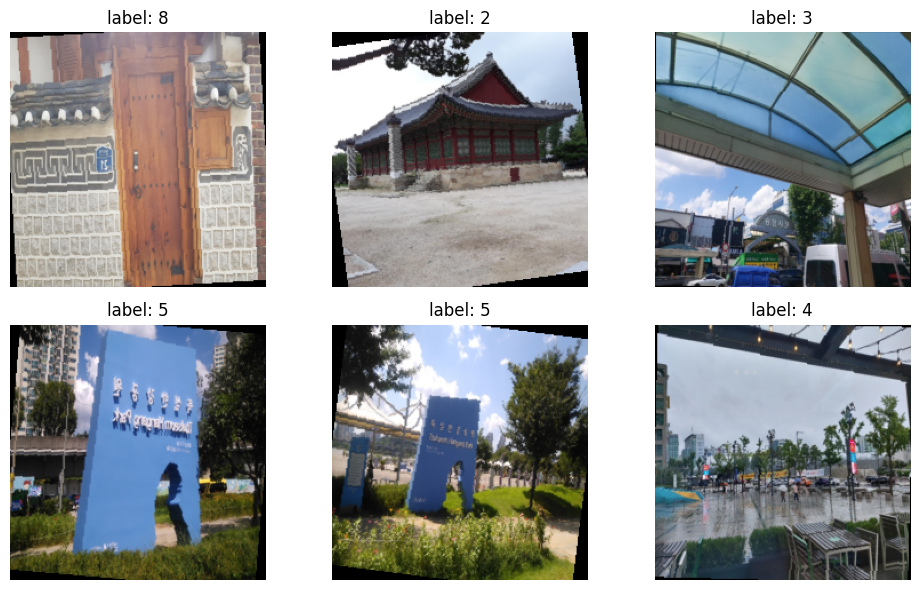

In [24]:
# 첫 번째 배치 꺼내서 확인
images, labels = next(iter(train_loader))
print(f"이미지 shape: {images.shape}")  # (32, 3, 224, 224)
print(f"라벨: {labels}")

# 첫 번째 배치에서 이미지 가져오기
images, labels = next(iter(train_loader))

# Normalize 되돌리기 (안 하면 색이 이상하게 보임)
def denormalize(tensor):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# 이미지 6장 출력
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i].clone())
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'label: {labels[i].item()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

전이학습 모델 정의

In [25]:
# ResNet18 불러오기
model_fe = models.resnet18(pretrained=False)
model_ft = models.resnet18(pretrained=False)

# 마지막 레이어 교체 (1000 → 10 클래스)
model_fe.fc = nn.Linear(512, 10)
model_ft.fc = nn.Linear(512, 10)

# Feature Extraction - backbone freeze
for param in model_fe.parameters():
    param.requires_grad = False
for param in model_fe.fc.parameters():
    param.requires_grad = True

print("모델 정의 완료")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


모델 정의 완료


학습 함수 정의 및 학습

In [26]:
def train_model(model, train_loader, val_loader, epochs=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    for epoch in range(epochs):
        # 학습
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # 검증
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {100*correct/total:.2f}%")

    return model

print("=== Feature Extraction ===")
model_fe = train_model(model_fe, train_loader, val_loader, epochs=5)

print("\n=== Fine-tuning ===")
model_ft = train_model(model_ft, train_loader, val_loader, epochs=5)

=== Feature Extraction ===
Epoch 1 | Train Loss: 2.3045 | Val Loss: 2.2713 | Val Acc: 11.72%
Epoch 2 | Train Loss: 2.2151 | Val Loss: 2.2337 | Val Acc: 14.48%
Epoch 3 | Train Loss: 2.1782 | Val Loss: 2.1001 | Val Acc: 31.03%
Epoch 4 | Train Loss: 2.1365 | Val Loss: 2.0519 | Val Acc: 24.83%
Epoch 5 | Train Loss: 2.0875 | Val Loss: 2.0253 | Val Acc: 33.10%

=== Fine-tuning ===
Epoch 1 | Train Loss: 1.2790 | Val Loss: 6.3918 | Val Acc: 31.72%
Epoch 2 | Train Loss: 0.5682 | Val Loss: 3.5570 | Val Acc: 33.79%
Epoch 3 | Train Loss: 0.4617 | Val Loss: 1.1019 | Val Acc: 65.52%
Epoch 4 | Train Loss: 0.4979 | Val Loss: 1.2201 | Val Acc: 65.52%
Epoch 5 | Train Loss: 0.5030 | Val Loss: 2.2309 | Val Acc: 47.59%


성능 비교

In [27]:
def get_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

fe_acc = get_accuracy(model_fe, val_loader)
ft_acc = get_accuracy(model_ft, val_loader)

print(f"Feature Extraction Val Acc : {fe_acc:.2f}%")
print(f"Fine-tuning Val Acc        : {ft_acc:.2f}%")

Feature Extraction Val Acc : 33.10%
Fine-tuning Val Acc        : 47.59%


test 예측 + submission_transfer.csv 생성

In [28]:
def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for images in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# Fine-tuning 모델로 예측
predictions = predict(model_ft, test_loader)

submission = sample_submission.copy()
submission['label'] = predictions
submission.to_csv(
    '/content/drive/MyDrive/seoul-landmark-teamproject/submission/submission_transfer.csv',
    index=False
)

print("submission_transfer.csv 생성 완료!")
print(submission.head())

submission_transfer.csv 생성 완료!
  file_name  label
0   001.PNG      3
1   002.PNG      8
2   003.PNG      9
3   004.PNG      3
4   005.PNG      5


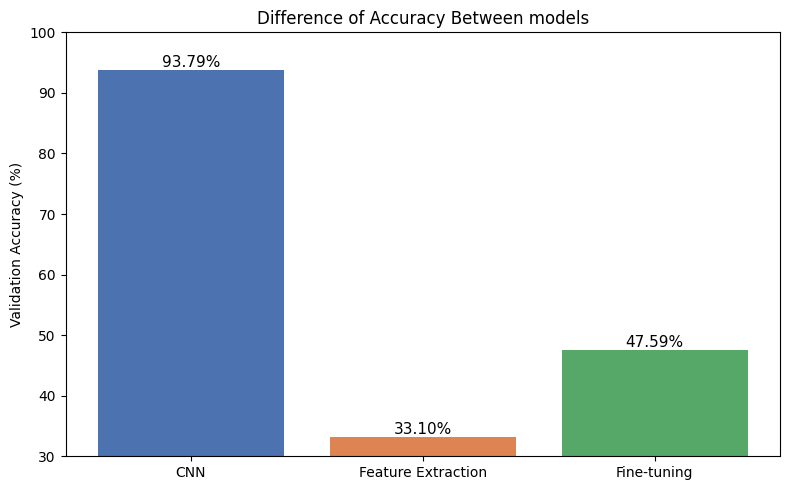

In [31]:
models_name = ['CNN', 'Feature Extraction', 'Fine-tuning']
accuracies  = [93.79, fe_acc, ft_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_name, accuracies, color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylim(30, 100)
plt.ylabel('Validation Accuracy (%)')
plt.title('Difference of Accuracy Between models')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/seoul-landmark-teamproject/results/model_comparison.png')
plt.show()